# 04 - Model Optimization
---
**Objective:** Improve the performance of the selected model (XGBoost) through hyperparameter tuning and optimization techniques.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
import warnings
warnings.filterwarnings('ignore')
from xgboost import XGBClassifier
from sklearn.metrics import (
    precision_recall_curve, f1_score, fbeta_score,
    average_precision_score, confusion_matrix,
    precision_score, recall_score
)

# Add project root to path
import os
import sys
sys.path.append(os.path.abspath('../'))
from src.data.loader import load_csv
from src.models.trainer import split_data, encoding, class_weights, clean_feature_names
from src.models.evaluator import evaluate_model, evaluate_threshold, plot_PR_curve
from src.models.optimization import find_optimal_threshold, eval_at_threshold

# Settings
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print("Libraries imported successfully!")
print(f"Python version: {sys.version.split()[0]}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully!
Python version: 3.13.5
Pandas version: 2.3.1
NumPy version: 2.3.2


In [ ]:
# Load data
train = load_csv('../data/external/train_top_features.csv')
print()
test = load_csv('../data/external/test_top_features.csv')

👉 Loading: ../data/processed/train_final.csv
DATASET INFORMATION
Shape: 1,296,675 rows × 31 columns
Memory usage: 770.12 MB

Column types:
int64      13
float64    11
object      7
Name: count, dtype: int64

Missing values: 0

👉 Loading: ../data/processed/test_final.csv
DATASET INFORMATION
Shape: 555,719 rows × 31 columns
Memory usage: 330.06 MB

Column types:
float64    12
int64      12
object      7
Name: count, dtype: int64

Missing values: 0


In [ ]:
X_train, y_train = split_data(train)
X_test,  y_test  = split_data(test)

X_train = clean_feature_names(X_train)
X_test  = clean_feature_names(X_test)

X_train, X_test = encoding(X_train, X_test)
scale_pos_weight = class_weights(y_train)

Feature shape: (1296675, 30)
scale_pos_weight: 171.75


## A. Threshold Optimization

In [ ]:
# Train baseline XGBoost (notebook-3 best params)
baseline = XGBClassifier(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='aucpr',
    early_stopping_rounds=30
)
baseline.fit(X_tr, y_train, eval_set=[(X_te, y_test)], verbose=False)

y_prob = baseline.predict_proba(X_te)[:, 1]


  Optimal threshold (F2 score)
  Threshold : 0.9447
  Precision : 0.7173
  Recall    : 0.8601
  F2 score : 0.8272

  Confusion Matrix @ threshold=0.9447
  TP=1845  FP=727  TN=552847  FN=300
  Fraud caught      : 86.0%  (recall)
  Alert precision   : 71.7%  (precision)
  False alert rate  : 0.13% of legit txns flagged



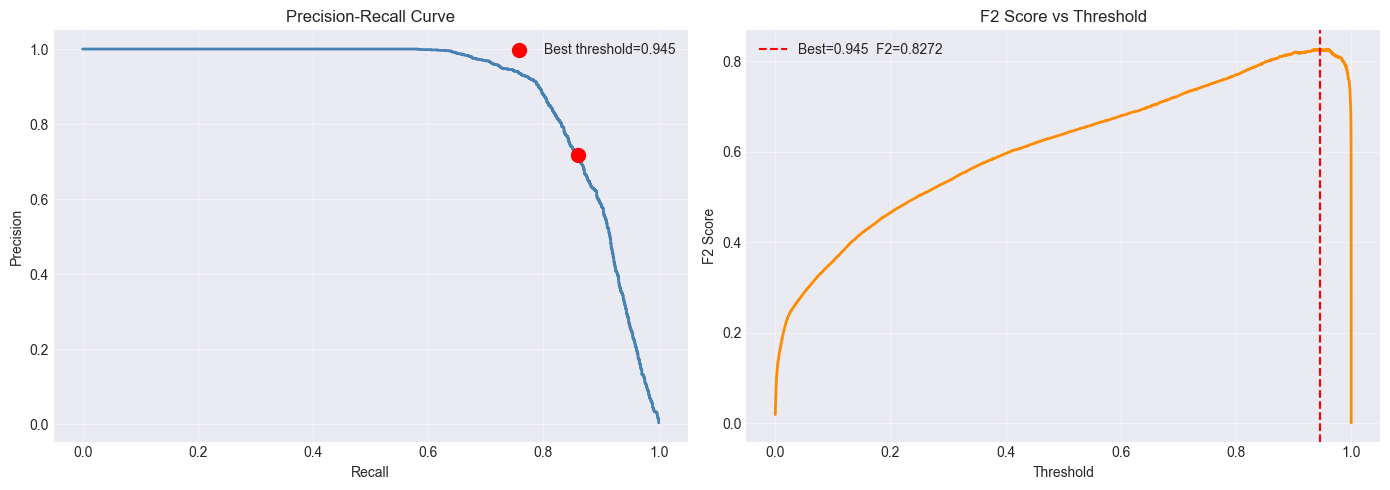

In [8]:
# ── Run threshold search ───────────────────────────────────────────────────────
# beta=2: recall is 2x more important than precision (typical for fraud)
# Change beta to match your business cost ratio
best_thr, thr_results = find_optimal_threshold(y_test, y_prob, beta=2)

## B. Hyperparameter Tuning with Optuna

In [9]:
def objective(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 200, 1000, step=100),
        'max_depth'         : trial.suggest_int('max_depth', 4, 12),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample'         : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight'  : trial.suggest_int('min_child_weight', 1, 20),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'gamma'             : trial.suggest_float('gamma', 0.0, 5.0),
        # fixed
        'scale_pos_weight'  : scale_pos_weight,
        'random_state'      : 42,
        'n_jobs'            : -1,
        'eval_metric'       : 'aucpr',
        'early_stopping_rounds': 30,
    }

    model = XGBClassifier(**params)
    model.fit(
        X_tr, y_train,
        eval_set=[(X_te, y_test)],
        verbose=False
    )

    # optimise PR-AUC (= average precision) — best metric for imbalanced fraud
    y_prob = model.predict_proba(X_te)[:, 1]
    return average_precision_score(y_test, y_prob)


# ── Run study ─────────────────────────────────────────────────────────────────
optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest PR-AUC : {study.best_value:.5f}")
print(f"Best params : {study.best_params}")

  0%|          | 0/50 [00:00<?, ?it/s]


Best PR-AUC : 0.89846
Best params : {'n_estimators': 1000, 'max_depth': 11, 'learning_rate': 0.029353677327286685, 'subsample': 0.9594989114993836, 'colsample_bytree': 0.9921428725888665, 'min_child_weight': 18, 'reg_alpha': 0.05618806605549532, 'reg_lambda': 0.09209018920691037, 'gamma': 1.6403165570406744}



  Optimal threshold (F2 score)
  Threshold : 0.9540
  Precision : 0.7826
  Recall    : 0.8476
  F2 score : 0.8337

  Confusion Matrix @ threshold=0.9540
  TP=1818  FP=505  TN=553069  FN=327
  Fraud caught      : 84.8%  (recall)
  Alert precision   : 78.3%  (precision)
  False alert rate  : 0.09% of legit txns flagged



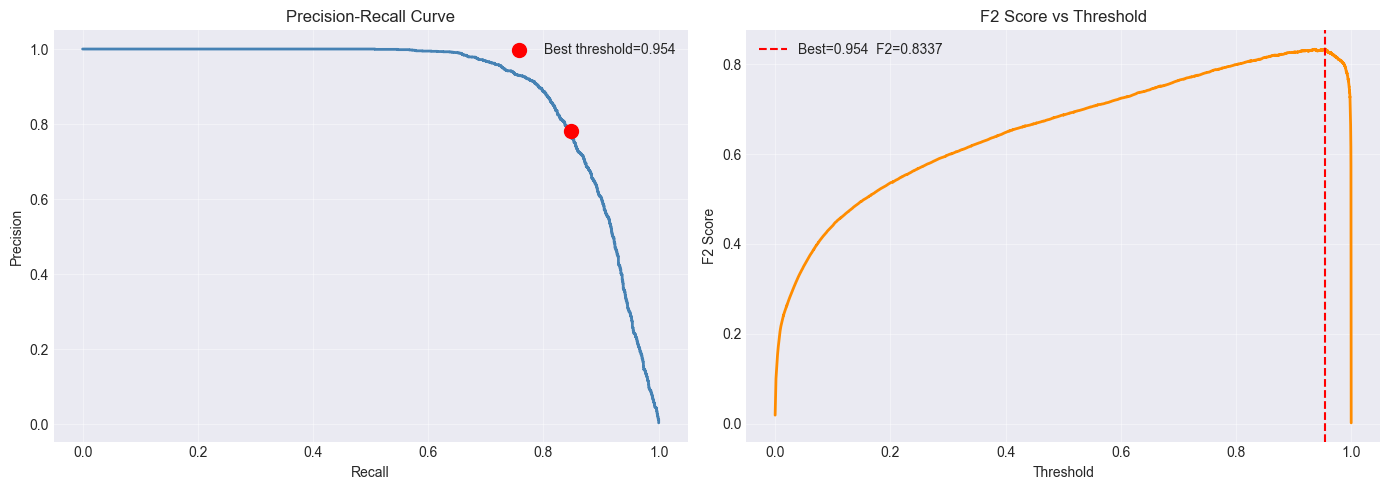

In [10]:
# ── Train final model with best params ────────────────────────────────────────
best_params = study.best_params
best_params.update({
    'scale_pos_weight'     : scale_pos_weight,
    'random_state'         : 42,
    'n_jobs'               : -1,
    'eval_metric'          : 'aucpr',
    'early_stopping_rounds': 30,
})

final_model = XGBClassifier(**best_params)
final_model.fit(
    X_tr, y_train,
    eval_set=[(X_te, y_test)],
    verbose=False
)

y_prob_final = final_model.predict_proba(X_te)[:, 1]

# find optimal threshold for tuned model
best_thr_final, _ = find_optimal_threshold(y_test, y_prob_final, beta=2)

In [8]:
# ── Baseline vs Tuned comparison ──────────────────────────────────────────────
eval_at_threshold(y_test, y_prob,       best_thr,       "Baseline XGBoost")
eval_at_threshold(y_test, y_prob_final, best_thr_final, "Tuned XGBoost")


── Baseline XGBoost (threshold=0.9447) ──
  PR-AUC    : 0.89377
  Precision : 0.7173
  Recall    : 0.8601
  F2        : 0.8272
  TP=1845  FP=727  TN=552847  FN=300

── Tuned XGBoost (threshold=0.9540) ──
  PR-AUC    : 0.89846
  Precision : 0.7826
  Recall    : 0.8476
  F2        : 0.8337
  TP=1818  FP=505  TN=553069  FN=327


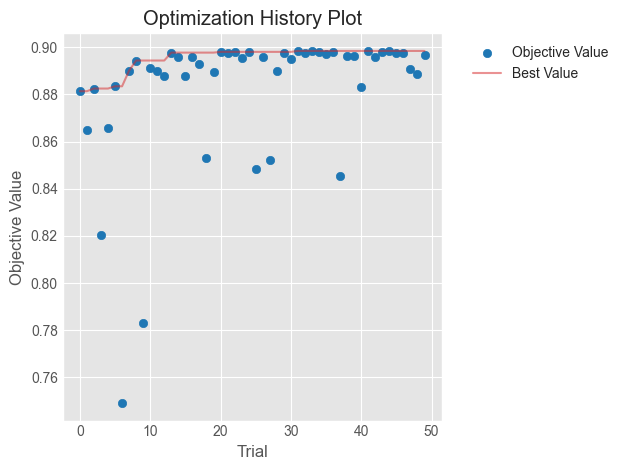

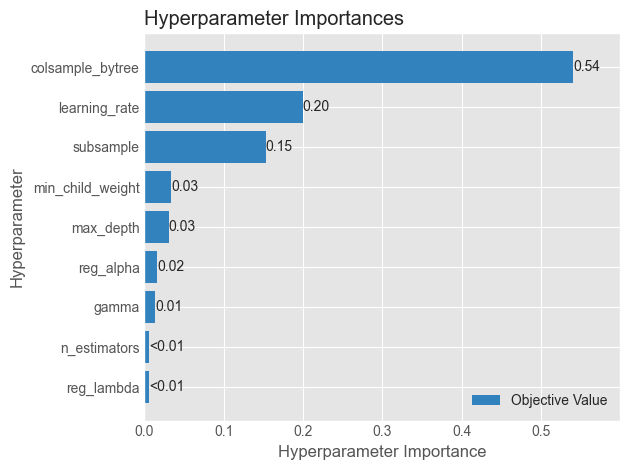

In [9]:
# ── Optuna visualisation ──────────────────────────────────────────────────────
fig = optuna.visualization.matplotlib.plot_optimization_history(study)
plt.tight_layout(); plt.show()

fig = optuna.visualization.matplotlib.plot_param_importances(study)
plt.tight_layout(); plt.show()